# NB_01 · Analyse Exploratoire des Données (EDA)
### Prédiction d'annulation de réservations d'hôtel

**Objectif de ce notebook :**
1. Collecter les données
2. Explorer le dataset (EDA)
3. Présenter les découvertes
4. Expliquer les problèmes identifiés (qui seront résolus dans `NB_02_Pretraitement`)


## 1. Collecte des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('../Donnees/hotel_bookings.csv')
print(f"Dimensions du dataset : {df.shape[0]} lignes x {df.shape[1]} colonnes")
df.head()


Dimensions du dataset : 119390 lignes x 32 colonnes


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

**Constat :** 119 390 réservations, 32 colonnes. Mélange de variables numériques
(`lead_time`, `adr`, `adults`...) et catégorielles (`hotel`, `meal`, `country`, `market_segment`...).
Variable cible : **`is_canceled`** (0 = maintenue, 1 = annulée).

## 2. Exploration (EDA)

### 2.1 Distribution de la variable cible

is_canceled
0    75166
1    44224
Name: count, dtype: int64
is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64


/tmp/ipykernel_567/3684694646.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_canceled', data=df, palette=['#2E86AB','#E63946'])


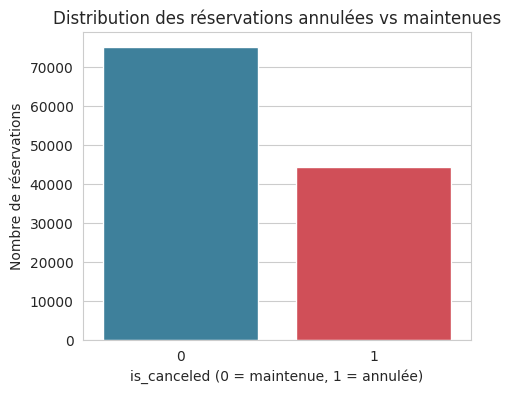

In [3]:
cancel_counts = df['is_canceled'].value_counts()
cancel_pct = df['is_canceled'].value_counts(normalize=True) * 100
print(cancel_counts)
print(cancel_pct.round(2))

plt.figure(figsize=(5,4))
sns.countplot(x='is_canceled', data=df, palette=['#2E86AB','#E63946'])
plt.title("Distribution des réservations annulées vs maintenues")
plt.xlabel("is_canceled (0 = maintenue, 1 = annulée)")
plt.ylabel("Nombre de réservations")
plt.show()


**Découverte :** ~37 % des réservations sont annulées contre 63 % maintenues.
Classes modérément déséquilibrées → l'accuracy seule ne suffira pas pour évaluer les modèles.

### 2.2 Valeurs manquantes

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'valeurs_manquantes': missing, 'pourcentage_%': missing_pct})
missing_summary = missing_summary[missing_summary['valeurs_manquantes'] > 0].sort_values('pourcentage_%', ascending=False)
missing_summary


,valeurs_manquantes,pourcentage_%
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


/tmp/ipykernel_567/3846650194.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_summary.index, y=missing_summary['pourcentage_%'], palette='Reds_r')


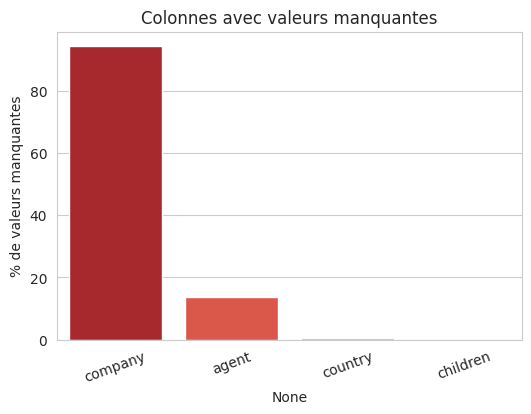

In [5]:
plt.figure(figsize=(6,4))
sns.barplot(x=missing_summary.index, y=missing_summary['pourcentage_%'], palette='Reds_r')
plt.ylabel('% de valeurs manquantes')
plt.title('Colonnes avec valeurs manquantes')
plt.xticks(rotation=20)
plt.show()


**Découverte :** `company` (~94 %), `agent` (~14 %), `country` (0,4 %), `children` (4 lignes).

### 2.3 Doublons

In [6]:
n_dup = df.duplicated().sum()
print(f"Lignes dupliquées : {n_dup} ({n_dup/len(df)*100:.2f}% du dataset)")


Lignes dupliquées : 31994 (26.80% du dataset)


**Découverte :** ~27 % des lignes sont des doublons stricts. À surveiller lors du prétraitement.

### 2.4 Variables numériques — statistiques et outliers

In [7]:
num_cols = ['lead_time','stays_in_weekend_nights','stays_in_week_nights','adults',
            'children','babies','adr','booking_changes','days_in_waiting_list',
            'previous_cancellations','total_of_special_requests']
df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0
adr,119390.0,101.831122,50.535790,-6.38,69.29,94.575,126.0,5400.0
booking_changes,119390.0,0.221124,0.652306,0.00,0.00,0.000,0.0,21.0
days_in_waiting_list,119390.0,2.321149,17.594721,0.00,0.00,0.000,0.0,391.0
previous_cancellations,119390.0,0.087118,0.844336,0.00,0.00,0.000,0.0,26.0


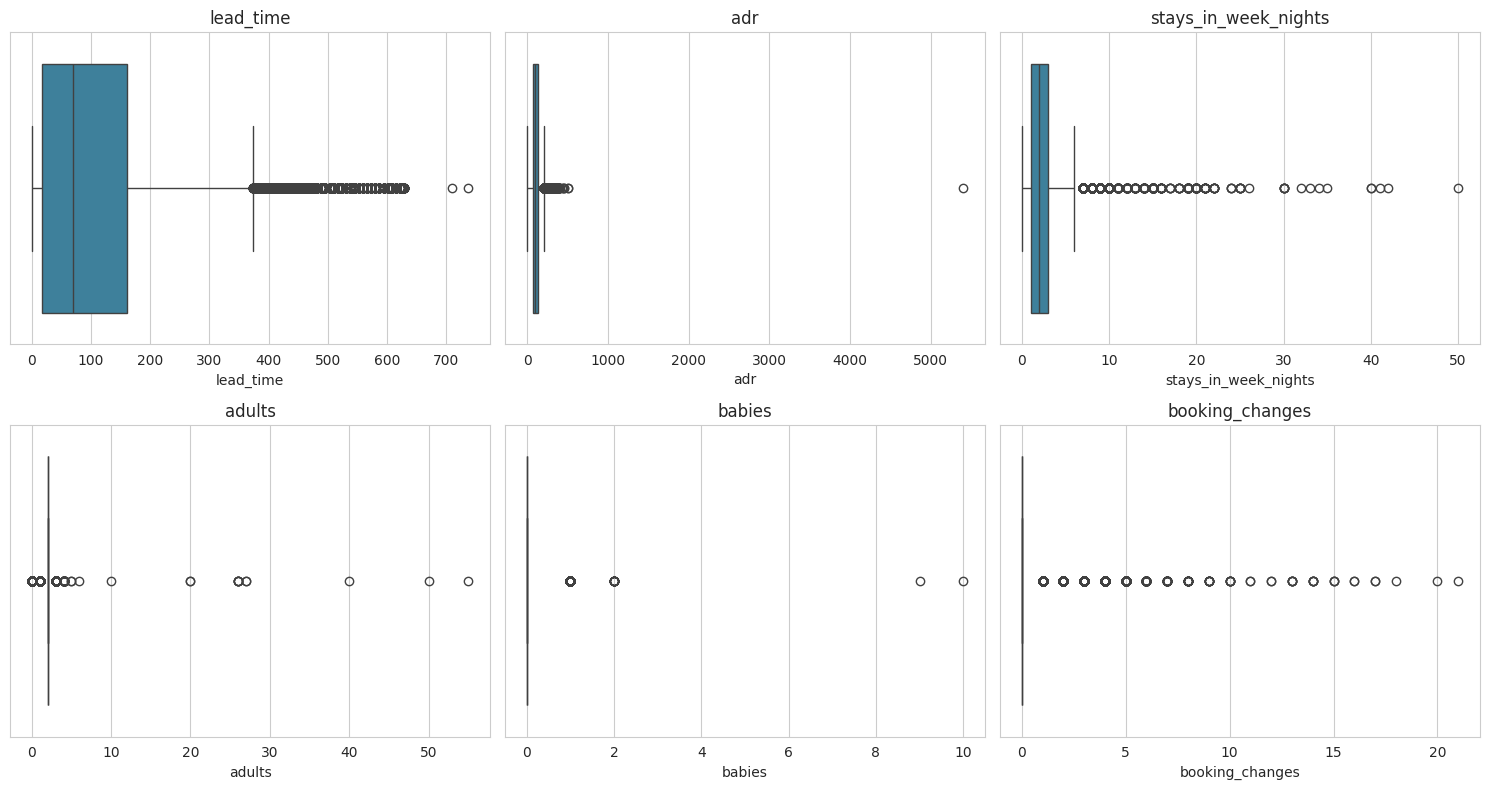

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))
outlier_cols = ['lead_time','adr','stays_in_week_nights','adults','babies','booking_changes']
for ax, col in zip(axes.flat, outlier_cols):
    sns.boxplot(x=df[col], ax=ax, color='#2E86AB')
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [9]:
print("ADR négatif :", (df['adr'] < 0).sum(), "ligne(s) — min =", df['adr'].min())
print("ADR > 1000 :", (df['adr'] > 1000).sum(), "ligne(s) — max =", df['adr'].max())
print("Réservations sans occupant (0 adulte/enfant/bébé) :",
      ((df['adults']==0) & (df['children'].fillna(0)==0) & (df['babies']==0)).sum())
print("lead_time max :", df['lead_time'].max(), "jours")


ADR négatif : 1 ligne(s) — min = -6.38
ADR > 1000 : 1 ligne(s) — max = 5400.0
Réservations sans occupant (0 adulte/enfant/bébé) : 180
lead_time max : 737 jours


**Découvertes / problèmes identifiés :**
- `adr` contient une valeur négative (-6.38) et un maximum extrême (5400) → erreurs probables.
- **180 réservations** sans aucun occupant → incohérent, à traiter.
- `lead_time` va jusqu'à 737 jours (extrême mais plausible, conservé).

### 2.5 Variables catégorielles

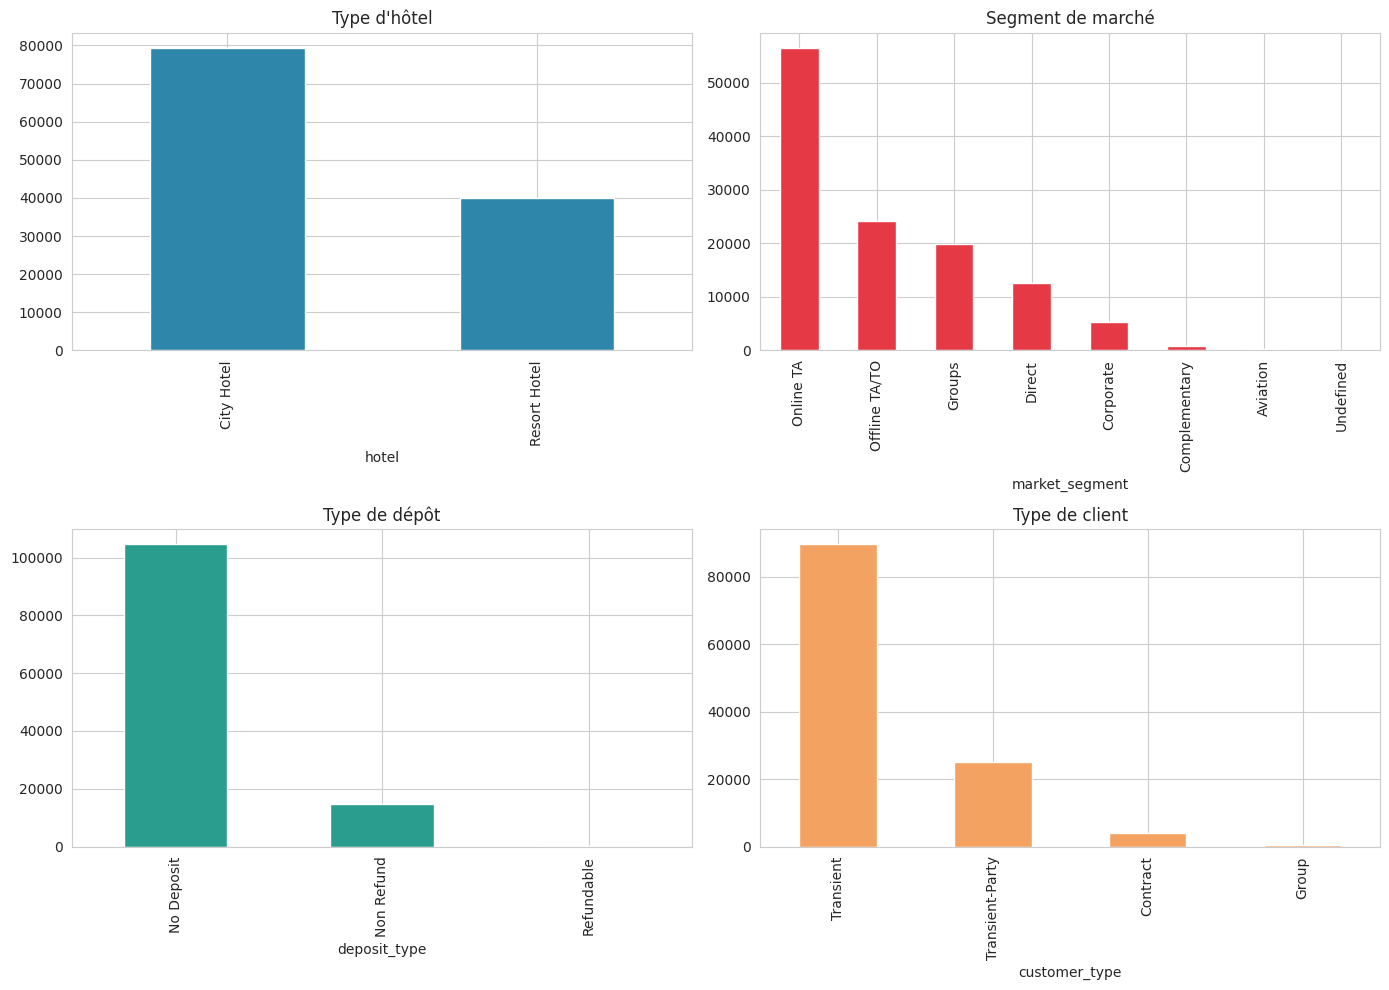

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))
df['hotel'].value_counts().plot(kind='bar', ax=axes[0,0], color='#2E86AB'); axes[0,0].set_title("Type d'hôtel")
df['market_segment'].value_counts().plot(kind='bar', ax=axes[0,1], color='#E63946'); axes[0,1].set_title('Segment de marché')
df['deposit_type'].value_counts().plot(kind='bar', ax=axes[1,0], color='#2A9D8F'); axes[1,0].set_title('Type de dépôt')
df['customer_type'].value_counts().plot(kind='bar', ax=axes[1,1], color='#F4A261'); axes[1,1].set_title('Type de client')
plt.tight_layout()
plt.show()


In [11]:
print("Taux d'annulation par hôtel (%) :\n", (df.groupby('hotel')['is_canceled'].mean()*100).round(2))
print("\nTaux d'annulation par dépôt (%) :\n", (df.groupby('deposit_type')['is_canceled'].mean()*100).round(2))


Taux d'annulation par hôtel (%) :
 hotel
City Hotel      41.73
Resort Hotel    27.76
Name: is_canceled, dtype: float64

Taux d'annulation par dépôt (%) :
 deposit_type
No Deposit    28.38
Non Refund    99.36
Refundable    22.22
Name: is_canceled, dtype: float64


**Découvertes :**
- City Hotel : ~42 % d'annulation vs Resort Hotel : ~28 %.
- Canal dominant : Online TA.
- `country`, `agent` ont une très forte cardinalité (beaucoup de catégories rares).

### 2.6 Corrélations (variables numériques vs cible)

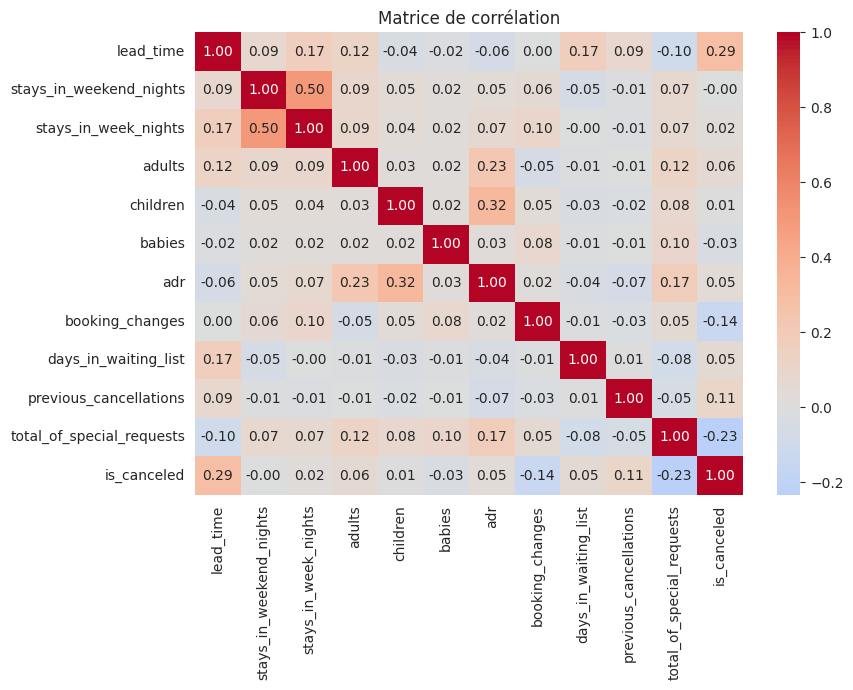

is_canceled                  1.000000
lead_time                    0.293123
previous_cancellations       0.110133
adults                       0.060017
days_in_waiting_list         0.054186
adr                          0.047557
stays_in_week_nights         0.024765
children                     0.005048
stays_in_weekend_nights     -0.001791
babies                      -0.032491
booking_changes             -0.144381
total_of_special_requests   -0.234658
Name: is_canceled, dtype: float64

In [12]:
corr_cols = num_cols + ['is_canceled']
corr = df[corr_cols].corr()
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()
corr['is_canceled'].sort_values(ascending=False)


**Découverte :** `lead_time` est la variable numérique la plus corrélée positivement avec l'annulation.
`total_of_special_requests` et `booking_changes` sont corrélées négativement.

## 3. Synthèse des découvertes

| Constat | Détail |
|---|---|
| Cible déséquilibrée | 63 % non annulées / 37 % annulées |
| Valeurs manquantes | `company` (94 %), `agent` (14 %), `country` (0,4 %), `children` (~0 %) |
| Doublons | ~27 % de lignes dupliquées |
| Outliers | `adr` négatif ou > 1000, 180 réservations sans occupant |
| Data leakage potentiel | `reservation_status`, `reservation_status_date` |
| Cardinalité élevée | `country`, `agent`, `company` |
| Signal fort | `lead_time` ↑ → annulation ↑ ; `total_of_special_requests` ↑ → annulation ↓ |

## 4. Problèmes identifiés (à résoudre dans NB_02_Pretraitement)

1. Valeurs manquantes à différents niveaux de gravité
2. Data leakage (`reservation_status*`)
3. Valeurs aberrantes (outliers)
4. Variables catégorielles non exploitables telles quelles (texte)
5. Cardinalité élevée de certaines variables
6. Échelles très différentes entre variables numériques

➡️ Suite du traitement dans **`NB_02_Pretraitement.ipynb`**.
